In [1]:
pip install pandas numpy matplotlib statsmodels scikit-learn streamlit plotly

  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/48/1d/40de1819374b4f0507411a60f4d2de0d620a9b10c817de5925799132b6c9/streamlit-1.54.0-py3-none-any.whl.metadata
  Obtaining dependency information for altair!=5.4.0,!=5.4.1,<7,>=4.0 from https://files.pythonhosted.org/packages/db/33/ef2f2409450ef6daa61459d5de5c08128e7d3edb773fefd0a324d1310238/altair-6.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for blinker<2,>=1.5.0 from https://files.pythonhosted.org/packages/10/cb/f2ad4230dc2eb1a74edf38f1a38b9b52277f75bef262d8908e60d957e13c/blinker-1.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for cachetools<7,>=5.5 from https://files.pythonhosted.org/packages/90/45/f458fa2c388e79dd9d8b9b0c99f1d31b568f27388f2fdba7bb66bbc0c6ed/cachetools-6.2.6-py3-none-any.whl.metadata
  Obtaining dependency information for gitpython!=3.1.19,<4,>=3.0.7 from https://files.pythonhosted.org/packages/6a/09/e21df6aef1e1ffc0c816f0522ddc3f6dcd

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math

np.random.seed(42)

# 3 years of data (important for seasonality learning)
dates = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')

# Strong yearly seasonal pattern
day_of_year = dates.dayofyear

seasonal_pattern = 50 * np.sin(2 * np.pi * day_of_year / 365)

# Base load
base = 250

# Controlled exam spike (May & November)
exam_effect = []
for date in dates:
    if date.month in [5, 11]:
        exam_effect.append(120)  # fixed spike
    else:
        exam_effect.append(0)

# Reduced noise
noise = np.random.normal(0, 5, len(dates))

energy = base + seasonal_pattern + exam_effect + noise

data = pd.DataFrame({
    "Date": dates,
    "Energy_Usage": energy
})

data.set_index("Date", inplace=True)

data.head()

,Energy_Usage
Date,
2022-01-01,253.344239
2022-01-02,251.029759
2022-01-03,255.819426
2022-01-04,261.055271
2022-01-05,253.127473


In [3]:
np.random.seed(42)

# Generate 2 years of daily data
dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')

# Base energy usage
base_usage = 200 + np.random.normal(0, 10, len(dates))

# Add exam season effect (May & November)
exam_effect = []
for date in dates:
    if date.month in [5, 11]:  # Exam months
        exam_effect.append(np.random.normal(80, 15))
    else:
        exam_effect.append(0)

energy_usage = base_usage + exam_effect

data = pd.DataFrame({
    'Date': dates,
    'Energy_Usage': energy_usage
})

data.set_index('Date', inplace=True)

data.head()

,Energy_Usage
Date,
2023-01-01,204.967142
2023-01-02,198.617357
2023-01-03,206.476885
2023-01-04,215.230299
2023-01-05,197.658466


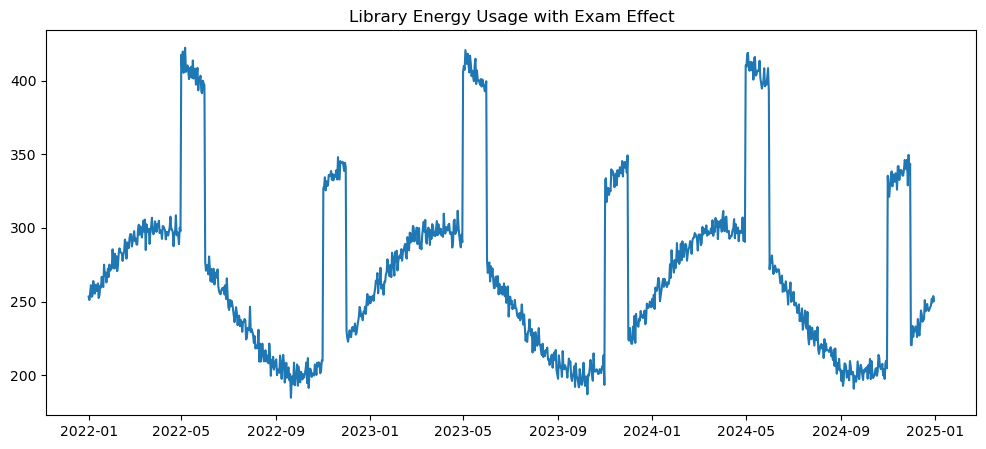

In [10]:
plt.figure(figsize=(12,5))
plt.plot(data['Energy_Usage'])
plt.title("Library Energy Usage with Exam Effect")
plt.show()

In [11]:
train = data[:'2024-06-30']
test = data['2024-07-01':]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 912
Test size: 184


In [12]:
model = ExponentialSmoothing(
    train['Energy_Usage'],
    trend='add',
    seasonal='add',
    seasonal_periods=365
)

fit_model = model.fit(optimized=True)

forecast = fit_model.forecast(len(test))

C:\Users\RITUL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [13]:
mae = mean_absolute_error(test['Energy_Usage'], forecast)
rmse = math.sqrt(mean_squared_error(test['Energy_Usage'], forecast))
r2 = r2_score(test['Energy_Usage'], forecast)

accuracy = r2 * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Accuracy (%):", accuracy)

MAE: 5.7853488207060915
RMSE: 13.738243461745682
R2 Score: 0.9110961923090278
Accuracy (%): 91.10961923090278


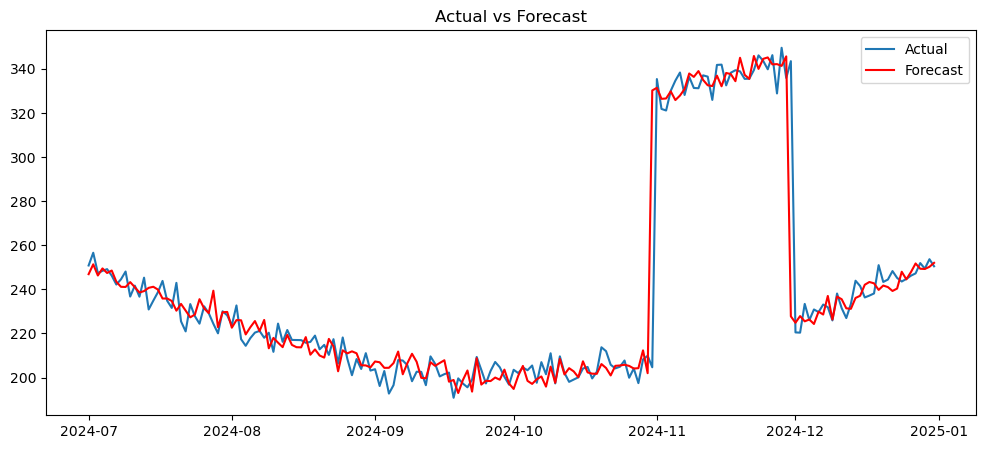

In [14]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test['Energy_Usage'], label="Actual")
plt.plot(test.index, forecast, label="Forecast", color='red')
plt.legend()
plt.title("Actual vs Forecast")
plt.show()